In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.optimize import root_scalar
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap


In [2]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,        # 默认字体大小
    "axes.labelsize": 10,   # 轴标签字体大小
    "legend.fontsize": 10,  # 图例字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

In [3]:
# 设置参数
m0 = 1
a0 = 9/10
rin0 = 6
rmax0 = 12
rout = 50
gamma = 4/3
rho_max = 1





In [4]:
# 定义事件视界
rh = m0 + np.sqrt(m0**2 - a0**2)

# 定义度规函数
def gtt(r, theta):
    return -1 + (2 * m0 * r) / (r**2 + a0**2 * np.cos(theta)**2)

def grr(r, theta):
    return (r**2 + a0**2 * np.cos(theta)**2) / (a0**2 - 2 * m0 * r + r**2)

def gtheta_theta(r, theta):
    return r**2 + a0**2 * np.cos(theta)**2

def gphi_phi(r, theta):
    return (a0**2 + r**2) * np.sin(theta)**2 + (2 * a0**2 * m0 * r * np.sin(theta)**4) / (r**2 + a0**2 * np.cos(theta)**2)

def gt_phi(r, theta):
    return -((2 * a0 * m0 * r * np.sin(theta)**2) / (r**2 + a0**2 * np.cos(theta)**2))

# 定义辅助函数
def nu(r, theta):
    return 0.5 * np.log(gt_phi(r, theta)**2 / gphi_phi(r, theta) - gtt(r, theta))

def lambda_func(r, theta):
    return 0.5 * np.log(grr(r, theta))

def mu(r, theta):
    return 0.5 * np.log(gtheta_theta(r, theta))

def psi(r, theta):
    return 0.5 * np.log(gphi_phi(r, theta))

def omega(r, theta):
    return -gt_phi(r, theta) / gphi_phi(r, theta)

def chi(r, theta):
    return psi(r, theta) - nu(r, theta)

# 定义q4函数
def q4(r, theta, l):
    chi_val = chi(r, theta)
    nu_val = nu(r, theta)
    omega_val = omega(r, theta)
    
    return 0.5 * np.log(1 + np.sqrt(1 + 4 * l**2 * np.exp(-2 * chi_val))) - \
           0.5 * np.sqrt(1 + 4 * l**2 * np.exp(-2 * chi_val)) - \
           l * omega_val - nu_val

# 定义lnh函数
def lnh(r, theta, l, rin):
    return q4(r, theta, l) - q4(rin, np.pi/2, l)

# 定义lnhd函数（lnh对r的导数，在theta=pi/2处）
def lnhd(r, l, rin):
    # 使用数值微分
    dr = 1e-7
    return (lnh(r + dr, np.pi/2, l, rin) - lnh(r - dr, np.pi/2, l, rin)) / (2 * dr)

# 找到l0（使得lnhd在rmax0处为0的l值）
def find_l0(rmax):
    def f(l):
        return lnhd(rmax, l, rin0)
    
    # 使用二分法查找根
    l_min, l_max = 0.001, 10.0
    result = root_scalar(f, bracket=[l_min, l_max], method='brentq', rtol=1e-10)
    return result.root

l0 = find_l0(rmax0)
print(f"l0 = {l0}")

# 计算lnhmax
lnhmax = lnh(rmax0, np.pi/2, l0, rin0)
print(f"lnhmax = {lnhmax}")

# 计算密度相关参数
pover_rho_peak = (gamma - 1) / gamma * (np.exp(lnhmax) - 1)
rho_amp = rho_max / (pover_rho_peak**(1/(gamma - 1)))

# 计算密度函数
def pover_rho_func(r, theta):
    return (gamma - 1) / gamma * (np.exp(lnh(r, theta, l0, rin0)) - 1)

def rho_func(r, theta):
    return rho_amp * pover_rho_func(r, theta)**(1/(gamma - 1))



l0 = 4.293150133089408
lnhmax = 0.016344720242908325


In [5]:
# 创建网格
resolution = 500
x = np.linspace(0, rout, resolution)
z = np.linspace(-rout/2, rout/2, resolution)
X, Z = np.meshgrid(x, z)

# 计算r和theta
R = np.sqrt(X**2 + Z**2)
THETA = np.arccos(Z / R)
THETA = np.where(np.isnan(THETA), 0, THETA)  # 处理除以零的情况

# 计算lnh和rho
LNH = np.zeros_like(R)
RHO = np.zeros_like(R)

# 定义并行处理函数
def process_point(args):
    i, j, r_val, theta_val = args
    lnh_val = np.nan
    rho_val = np.nan
    
    # 排除事件视界内部
    if r_val <= rh:
        pass
    # 排除内半径内部
    elif r_val <= rin0:
        pass
    else:
        lnh_val = lnh(r_val, theta_val, l0, rin0)
        # 只计算LNH为正的区域的密度
        if lnh_val > 0 and lnh_val <= lnhmax:
            rho_val = rho_func(r_val, theta_val)
    
    return (i, j, lnh_val, rho_val)

# 准备参数
args_list = []
for i in range(resolution):
    for j in range(resolution):
        args_list.append((i, j, R[i, j], THETA[i, j]))

# 使用多进程并行计算
from multiprocessing import Pool, cpu_count
num_processes = cpu_count()
with Pool(processes=num_processes) as pool:
    results = pool.map(process_point, args_list)

# 将结果填回数组
for i, j, lnh_val, rho_val in results:
    LNH[i, j] = lnh_val
    RHO[i, j] = rho_val




/tmp/ipykernel_467997/3345302013.py:31: RuntimeWarning: divide by zero encountered in log
  return 0.5 * np.log(gphi_phi(r, theta))
/tmp/ipykernel_467997/3345302013.py:22: RuntimeWarning: invalid value encountered in scalar divide
  return 0.5 * np.log(gt_phi(r, theta)**2 / gphi_phi(r, theta) - gtt(r, theta))
/tmp/ipykernel_467997/3345302013.py:34: RuntimeWarning: invalid value encountered in scalar divide
  return -gt_phi(r, theta) / gphi_phi(r, theta)
/tmp/ipykernel_467997/3345302013.py:31: RuntimeWarning: divide by zero encountered in log
  return 0.5 * np.log(gphi_phi(r, theta))
/tmp/ipykernel_467997/3345302013.py:22: RuntimeWarning: invalid value encountered in scalar divide
  return 0.5 * np.log(gt_phi(r, theta)**2 / gphi_phi(r, theta) - gtt(r, theta))
/tmp/ipykernel_467997/3345302013.py:34: RuntimeWarning: invalid value encountered in scalar divide
  return -gt_phi(r, theta) / gphi_phi(r, theta)
/tmp/ipykernel_467997/3345302013.py:31: RuntimeWarning: divide by zero encountered i

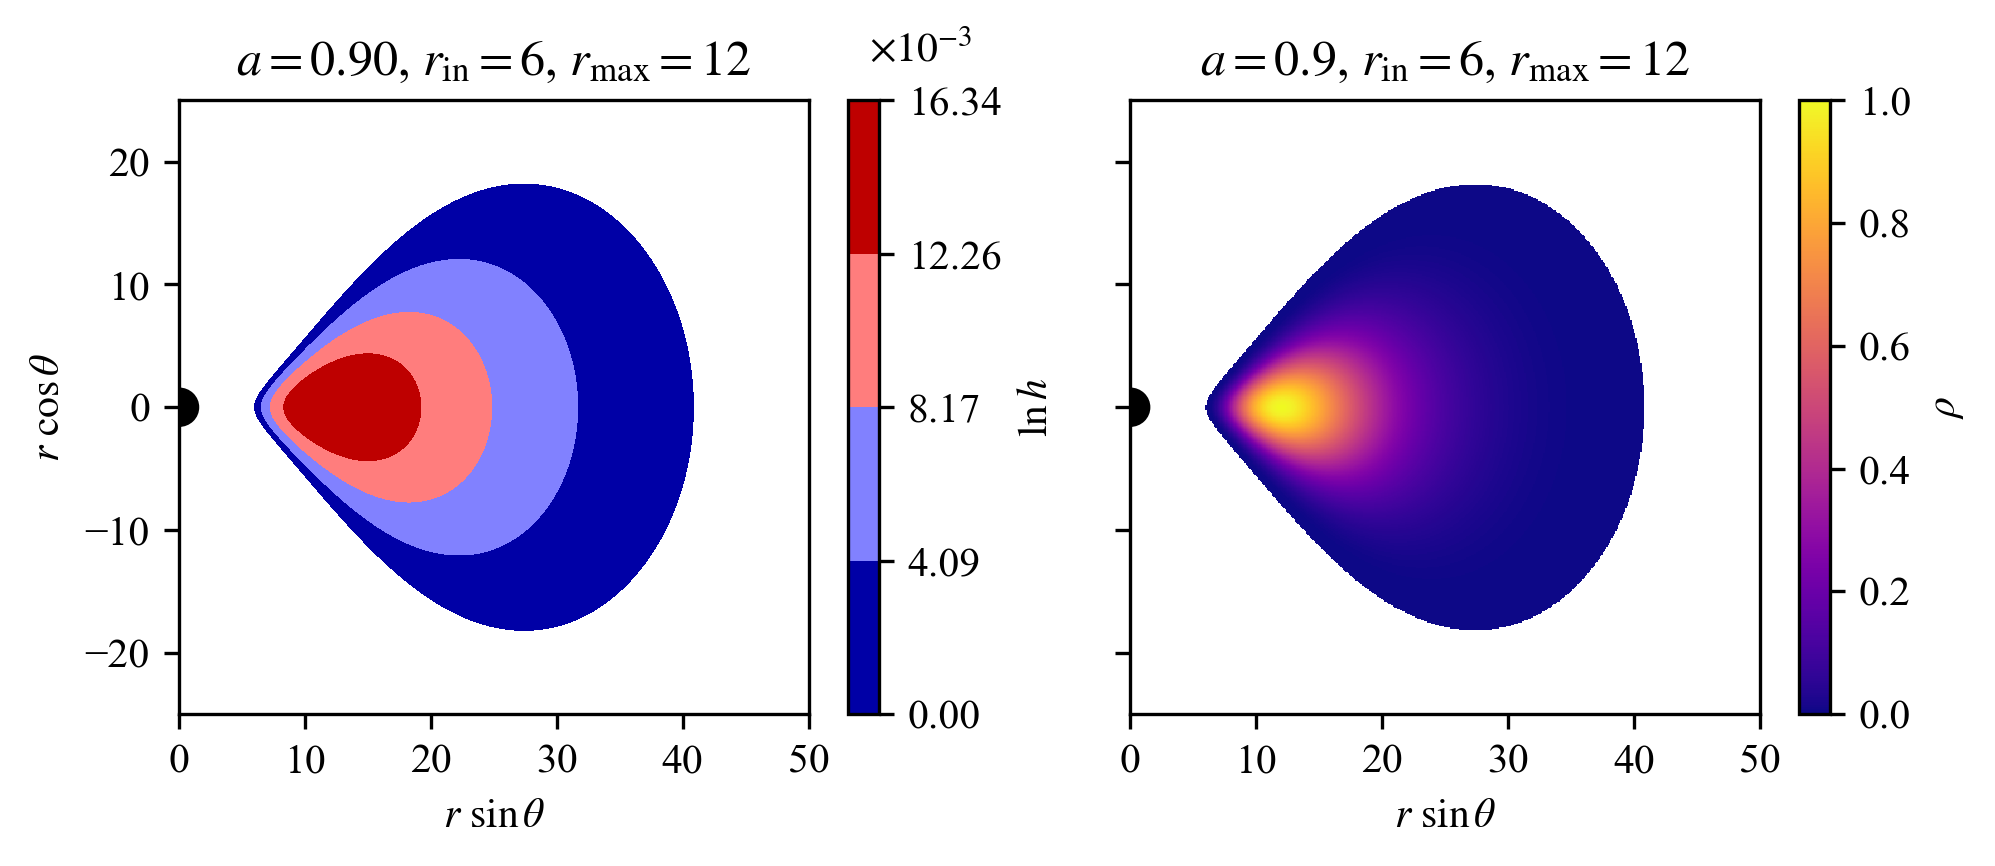

In [7]:
# 绘图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.8, 3), dpi=300, sharey=True)

# 获取原始的 rainbow colormap
rainbow = plt.get_cmap('rainbow')

# 调整 colormap 的亮度或饱和度
# 这里我们将颜色变深
colors = rainbow(np.linspace(0, 1, 256))
colors = colors * 0.9  # 通过乘法调整亮度，值越小颜色越深
new_cmap = ListedColormap(colors)

# 绘制lnh的等高线图
contour = ax1.contourf(X, Z, LNH, levels=np.linspace(0, lnhmax, 5), cmap="seismic")
ax1.set_xlim(0, rout)
ax1.set_ylim(-rout/2, rout/2)
ax1.set_xlabel(r'$r~\sin\theta$')
ax1.set_ylabel(r'$r~\cos\theta$')
ax1.set_title(f'$a = {a0:.2f}$, $r_{{\mathrm{{in}}}} = {rin0:.0f}$, $r_{{\mathrm{{max}}}} = {rmax0:.0f}$')
ax1.add_patch(patches.Circle((0, 0), rh, color='black', fill=True))

# 创建colorbar并设置格式化，使值乘以10^3并保留2位小数
cbar = fig.colorbar(contour, ax=ax1)
cbar.set_label(r'$\ln h$')
cbar.formatter = plt.FuncFormatter(lambda x, pos: f'{(x*1000):.2f}')
cbar.ax.text(0.7, 1.05, r'$\times 10^{-3}$', 
             transform=cbar.ax.transAxes, ha='left', va='bottom', fontsize=10)
cbar.update_ticks()


# 绘制密度图
density = ax2.pcolormesh(X, Z, RHO, cmap='plasma', vmin=0, vmax=1)
ax2.set_xlim(0, rout)
ax2.set_ylim(-rout/2, rout/2)
ax2.set_xlabel(r'$r~\sin\theta$')
# ax2.set_ylabel(r'$r~\cos\theta$')
ax2.set_title(f'$a = {a0}$, $r_{{\mathrm{{in}}}} = {rin0:.0f}$, $r_{{\mathrm{{max}}}} = {rmax0:.0f}$')
ax2.add_patch(patches.Circle((0, 0), rh, color='black', fill=True))
fig.colorbar(density, ax=ax2, label=r'$\rho$')

plt.tight_layout()
plt.savefig('FM-torus.png', dpi=300)
plt.show()